In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.datasets import fetch_openml
X, y = fetch_openml('mnist_784', return_X_y=True,)
print(X.shape, y.shape)

(70000, 784) (70000,)


In [3]:

X 

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


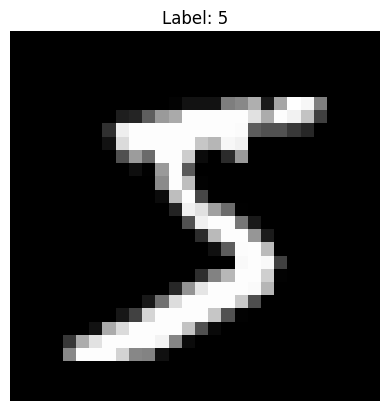

In [4]:
Imageindex = 0
imagedata = X.values[Imageindex].reshape(28, 28)
plt.imshow(imagedata, cmap='gray')  
plt.title(f"Label: {y[Imageindex]}")
plt.axis('off')
plt.show()


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
y_pred = model.predict(X_test) 
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print(classification_report(y_test, y_pred)) 

Accuracy: 0.9196666666666666
Precision: 0.9194362729248023
Recall: 0.9196666666666666
F1 Score: 0.9194948680400487
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2058
           1       0.95      0.98      0.96      2364
           2       0.91      0.90      0.91      2133
           3       0.90      0.90      0.90      2176
           4       0.92      0.93      0.93      1936
           5       0.89      0.86      0.88      1915
           6       0.94      0.95      0.95      2088
           7       0.94      0.94      0.94      2248
           8       0.88      0.87      0.87      1992
           9       0.90      0.90      0.90      2090

    accuracy                           0.92     21000
   macro avg       0.92      0.92      0.92     21000
weighted avg       0.92      0.92      0.92     21000



In [7]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("SVM Recall:", recall_score(y_test, y_pred_svm, average='weighted'))
print("SVM F1 Score:", f1_score(y_test, y_pred_svm, average='weighted'))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9762857142857143
SVM Precision: 0.976279672551265
SVM Recall: 0.9762857142857143
SVM F1 Score: 0.97626260197505
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2058
           1       0.98      0.99      0.99      2364
           2       0.97      0.98      0.97      2133
           3       0.97      0.97      0.97      2176
           4       0.97      0.98      0.97      1936
           5       0.98      0.97      0.97      1915
           6       0.98      0.99      0.99      2088
           7       0.97      0.97      0.97      2248
           8       0.98      0.96      0.97      1992
           9       0.97      0.96      0.97      2090

    accuracy                           0.98     21000
   macro avg       0.98      0.98      0.98     21000
weighted avg       0.98      0.98      0.98     21000



In [8]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf, average='weighted'))
print("Random Forest F1 Score:", f1_score(y_test, y_pred_rf, average='weighted'))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9667619047619047
Random Forest Precision: 0.966741079774148
Random Forest Recall: 0.9667619047619047
Random Forest F1 Score: 0.9667396715716733
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2058
           1       0.98      0.99      0.98      2364
           2       0.96      0.97      0.96      2133
           3       0.96      0.95      0.95      2176
           4       0.97      0.97      0.97      1936
           5       0.97      0.96      0.97      1915
           6       0.98      0.99      0.98      2088
           7       0.96      0.96      0.96      2248
           8       0.96      0.95      0.95      1992
           9       0.95      0.95      0.95      2090

    accuracy                           0.97     21000
   macro avg       0.97      0.97      0.97     21000
weighted avg       0.97      0.97      0.97     21000



In [9]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Precision:", precision_score(y_test, y_pred_dt, average='weighted'))
print("Decision Tree Recall:", recall_score(y_test, y_pred_dt, average='weighted'))
print("Decision Tree F1 Score:", f1_score(y_test, y_pred_dt, average='weighted'))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8683809523809524
Decision Tree Precision: 0.8680449734835236
Decision Tree Recall: 0.8683809523809524
Decision Tree F1 Score: 0.8681280062560303
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2058
           1       0.94      0.96      0.95      2364
           2       0.86      0.84      0.85      2133
           3       0.83      0.84      0.84      2176
           4       0.85      0.87      0.86      1936
           5       0.83      0.81      0.82      1915
           6       0.90      0.90      0.90      2088
           7       0.91      0.90      0.91      2248
           8       0.82      0.78      0.80      1992
           9       0.83      0.84      0.83      2090

    accuracy                           0.87     21000
   macro avg       0.87      0.87      0.87     21000
weighted avg       0.87      0.87      0.87     21000



In [10]:
from xgboost import XGBClassifier
y_trainXGB = y_train.astype(int)
X_trainXGB = X_train.astype(int)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_trainXGB, y_trainXGB)
y_pred_xgb = xgb_model.predict(X_test.astype(int))
y_test_int = y_test.astype(int)
print("XGBoost Accuracy:", accuracy_score(y_test_int, y_pred_xgb))
print("XGBoost Precision:", precision_score(y_test_int, y_pred_xgb, average='weighted'))
print("XGBoost Recall:", recall_score(y_test_int, y_pred_xgb, average='weighted'))
print("XGBoost F1 Score:", f1_score(y_test_int, y_pred_xgb, average='weighted'))
print(classification_report(y_test_int, y_pred_xgb))


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:45:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9762380952380952
XGBoost Precision: 0.9762518703042825
XGBoost Recall: 0.9762380952380952
XGBoost F1 Score: 0.9762327214268623
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2058
           1       0.98      0.99      0.99      2364
           2       0.97      0.98      0.97      2133
           3       0.98      0.96      0.97      2176
           4       0.97      0.98      0.98      1936
           5       0.98      0.97      0.98      1915
           6       0.98      0.99      0.98      2088
           7       0.97      0.98      0.97      2248
           8       0.97      0.97      0.97      1992
           9       0.96      0.97      0.96      2090

    accuracy                           0.98     21000
   macro avg       0.98      0.98      0.98     21000
weighted avg       0.98      0.98      0.98     21000



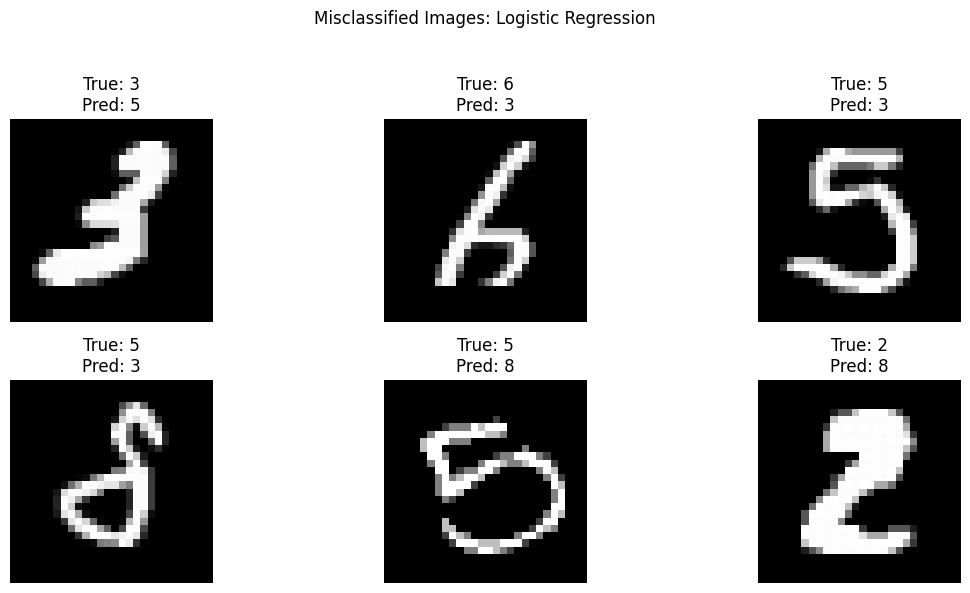

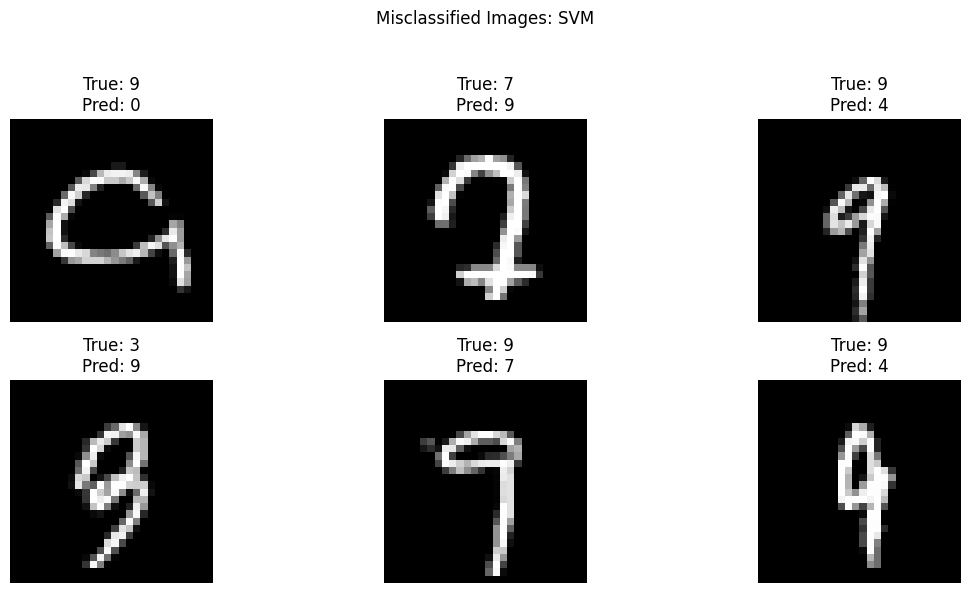

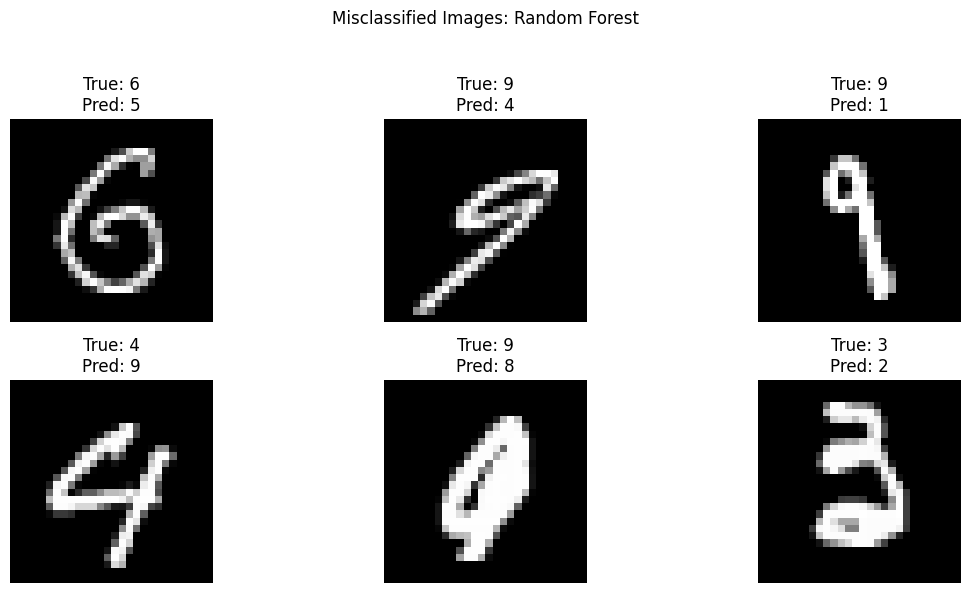

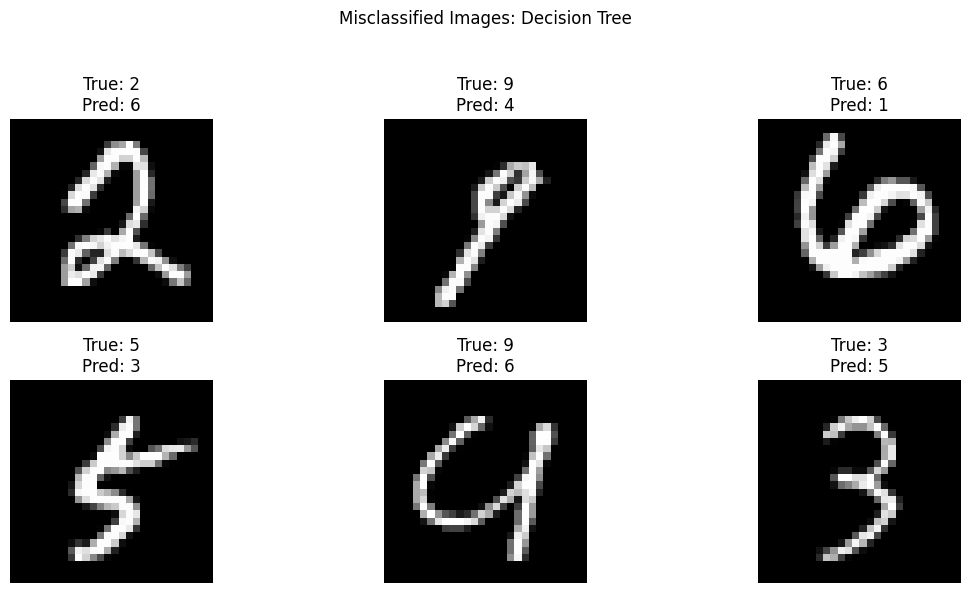

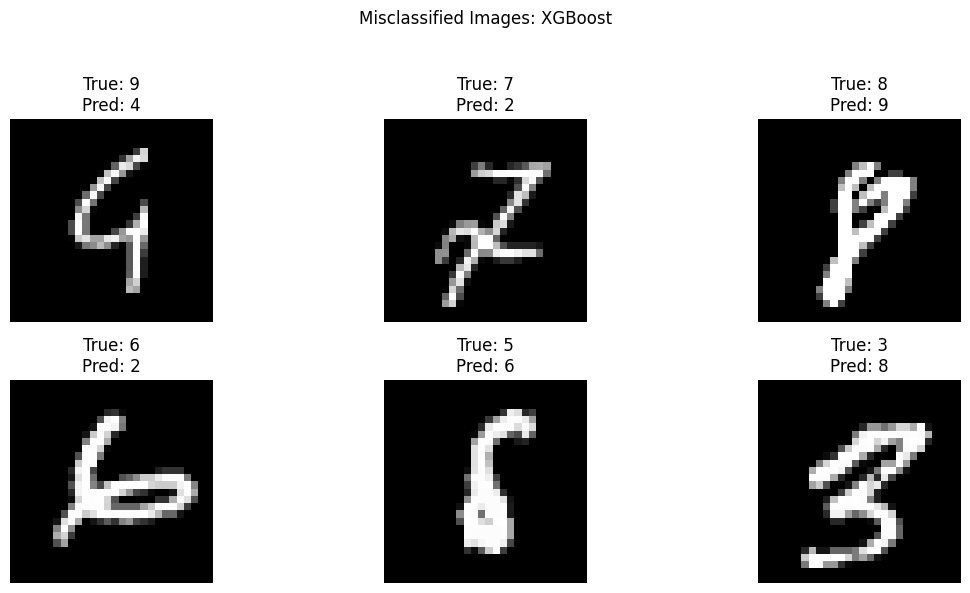

In [11]:
import random

def plot_misclassified_images(X_test, y_test, y_pred, model_name, num_images=6):
    misclassified_indices = [i for i, (true, pred) in enumerate(zip(y_test, y_pred)) if true != pred]
    if len(misclassified_indices) == 0:
        print(f"No misclassified images for {model_name}.")
        return
    sample_indices = random.sample(misclassified_indices, min(num_images, len(misclassified_indices)))
    plt.figure(figsize=(12, 6))
    for idx, mis_idx in enumerate(sample_indices):
        image = X_test.iloc[mis_idx].values.reshape(28, 28)
        plt.subplot(2, (num_images+1)//2, idx+1)
        plt.imshow(image, cmap='gray')
        plt.title(f"True: {y_test.iloc[mis_idx]}\nPred: {y_pred[mis_idx]}")
        plt.axis('off')
    plt.suptitle(f"Misclassified Images: {model_name}")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Logistic Regression
plot_misclassified_images(X_test, y_test, y_pred, "Logistic Regression")

# SVM
plot_misclassified_images(X_test, y_test, y_pred_svm, "SVM")

# Random Forest
plot_misclassified_images(X_test, y_test, y_pred_rf, "Random Forest")

# Decision Tree
plot_misclassified_images(X_test, y_test, y_pred_dt, "Decision Tree")

# XGBoost (ensure y_test is int for XGBoost)
plot_misclassified_images(X_test.astype(int), y_test.astype(int), y_pred_xgb, "XGBoost")

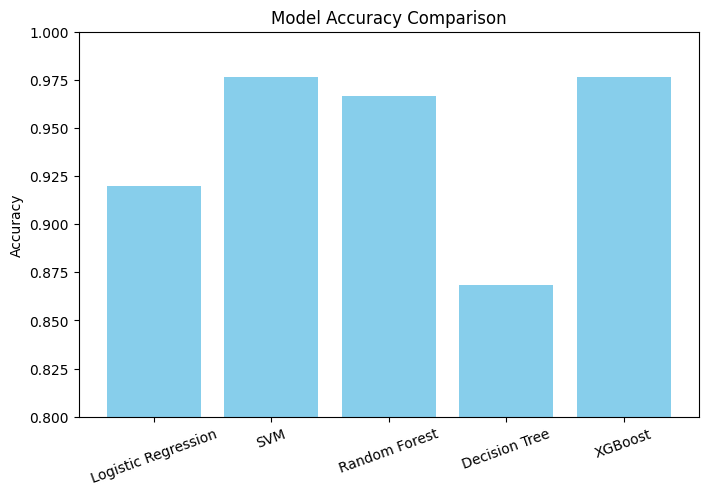

                 Model  Accuracy
0  Logistic Regression  0.919667
1                  SVM  0.976286
2        Random Forest  0.966762
3        Decision Tree  0.868381
4              XGBoost  0.976238


In [12]:
import pandas as pd
import matplotlib.pyplot as plt


accuracies = {
    'Logistic Regression': accuracy_score(y_test, y_pred),
    'SVM': accuracy_score(y_test, y_pred_svm),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'XGBoost': accuracy_score(y_test_int, y_pred_xgb)
}


acc_df = pd.DataFrame(list(accuracies.items()), columns=['Model', 'Accuracy'])


plt.figure(figsize=(8,5))
plt.bar(acc_df['Model'], acc_df['Accuracy'], color='skyblue')
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=20)
plt.show()


print(acc_df)

